# Simulación Monte Carlo – Coca-Cola (KO)

**Periodo de datos:** 1 de enero de 2026 al 31 de agosto de 2026

### Objetivo
1. Descargar los datos de KO con `yfinance`.
2. Dividir los datos en **train** y **test**.
3. Calcular los rendimientos de train.
4. Obtener **μ (mu)** y **σ (sigma)**.
5. Generar **10,000 posibles precios de KO al 1 de junio de 2026** mediante Monte Carlo.
6. Comparar el precio promedio simulado con el precio real.


## 1. Importar librerías

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Descargar los datos de KO

In [2]:
df = yf.download(
    'KO',
    start='2026-01-01',
    end='2026-09-01',
    auto_adjust=False
)

df

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,KO,KO,KO,KO,KO,KO
Date,,,,,,
2026-01-02,68.207611,69.120003,69.870003,68.980003,69.849998,12151300
2026-01-05,67.043182,67.940002,68.919998,67.919998,68.919998,21186600
2026-01-06,66.944496,67.839996,68.250000,67.589996,68.010002,21019900
2026-01-07,66.648468,67.540001,68.070000,67.269997,67.989998,20223400
2026-01-08,68.454315,69.370003,69.459999,67.449997,67.540001,19237000
...,...,...,...,...,...,...
2026-08-24,91.989998,91.989998,92.489998,91.449997,92.120003,14787700
2026-08-25,91.639999,91.639999,92.080002,91.300003,91.570000,11940100


## 3. Quedarnos con el precio de cierre

In [3]:
df = df[['Close']]

# Por si yfinance devuelve columnas múltiples
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

Price,Close
Date,
2026-01-02,69.120003
2026-01-05,67.940002
2026-01-06,67.839996
2026-01-07,67.540001
2026-01-08,69.370003


## 4. Dividir los datos en Train y Test

- **Train:** 1 de enero al 30 de abril de 2026
- **Test:** 1 de mayo al 30 de junio de 2026


In [4]:
train = df.loc['2026-01-01':'2026-04-30'].copy()
test = df.loc['2026-05-01':'2026-06-30'].copy()

print("Datos de train:", len(train))
print("Datos de test:", len(test))

Datos de train: 82
Datos de test: 41


### Ver train

In [5]:
train

Price,Close
Date,
2026-01-02,69.120003
2026-01-05,67.940002
2026-01-06,67.839996
2026-01-07,67.540001
2026-01-08,69.370003
...,...
2026-04-24,76.629997
2026-04-27,75.440002
2026-04-28,78.349998


### Ver test

In [6]:
test

Price,Close
Date,
2026-05-01,78.580002
2026-05-04,78.190002
2026-05-05,78.480003
2026-05-06,79.230003
2026-05-07,78.430000
2026-05-08,78.419998
2026-05-11,78.660004
2026-05-12,80.029999
2026-05-13,80.260002


## 5. Calcular los rendimientos del Train

In [7]:
train['Rendimiento'] = train['Close'].pct_change()

train

Price,Close,Rendimiento
Date,,
2026-01-02,69.120003,NaN
2026-01-05,67.940002,-0.017072
2026-01-06,67.839996,-0.001472
2026-01-07,67.540001,-0.004422
2026-01-08,69.370003,0.027095
...,...,...
2026-04-24,76.629997,0.004588
2026-04-27,75.440002,-0.015529
2026-04-28,78.349998,0.038574


In [8]:
rendimientos = train['Rendimiento'].dropna()

rendimientos

Date
2026-01-05   -0.017072
2026-01-06   -0.001472
2026-01-07   -0.004422
2026-01-08    0.027095
2026-01-09    0.016434
                ...   
2026-04-24    0.004588
2026-04-27   -0.015529
2026-04-28    0.038574
2026-04-29    0.006637
2026-04-30   -0.001395
Name: Rendimiento, Length: 81, dtype: float64

## 6. Calcular μ y σ

- **μ (mu):** rendimiento promedio diario.
- **σ (sigma):** volatilidad diaria, calculada con desviación estándar muestral.


In [9]:
mu = np.mean(rendimientos)

sigma = np.std(rendimientos, ddof=1)

print("Mu:", mu)
print("Sigma:", sigma)

Mu: 0.0016784098777531137
Sigma: 0.011522208217143925


## 7. Precio inicial

Tomamos como `S0` el primer precio disponible del periodo de test.


In [10]:
S0 = test['Close'].iloc[0]

print("S0:", S0)

S0: 78.58000183105469


## 8. Número de días hasta el 1 de junio

Como μ y σ son diarios, `T` será el número de días de operación desde el inicio del test hasta el 1 de junio.


In [11]:
T = len(test.loc[:'2026-06-01']) - 1

print("T:", T)

T: 20


## 9. Generar 10,000 posibles precios al 1 de junio

In [17]:
M = 10000

np.random.seed(32)

precios = []

for i in range(M):

    Z = np.random.normal(0, 1)

    ST = S0 * np.exp(
        (mu - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    precios.append(ST)

len(precios)
mu

np.float64(0.0016784098777531137)

In [23]:
S0

np.float64(78.58000183105469)

## 10. Histograma de los precios simulados

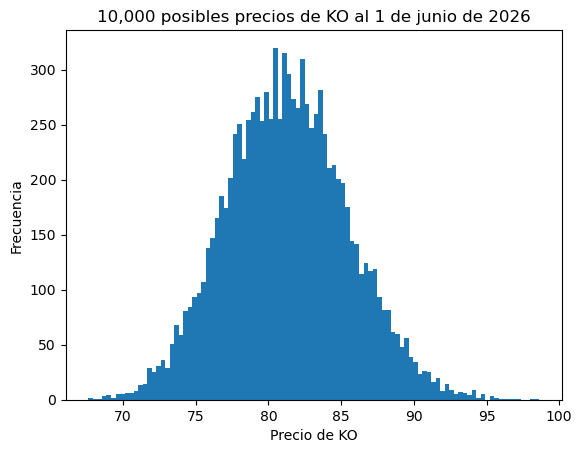

In [13]:
plt.hist(precios, bins=100)

plt.xlabel('Precio de KO')
plt.ylabel('Frecuencia')
plt.title('10,000 posibles precios de KO al 1 de junio de 2026')

plt.show()

## 11. Precio promedio simulado

In [14]:
precio_promedio = np.mean(precios)

print("Precio promedio simulado:", precio_promedio)
print("Precio mínimo simulado:", np.min(precios))
print("Precio máximo simulado:", np.max(precios))

Precio promedio simulado: 81.30316910594144
Precio mínimo simulado: 67.62234195926546
Precio máximo simulado: 98.63545566167586


## 12. Comparar contra el precio real

In [15]:
precio_real = test.loc['2026-06-01', 'Close']

print("Precio promedio simulado:", precio_promedio)
print("Precio real al 1 de junio:", precio_real)

Precio promedio simulado: 81.30316910594144
Precio real al 1 de junio: 78.63999938964844


In [31]:
precio_menor_razonable = np.percentile(precios, 95)

precio_menor_razonable
T


20

## Fórmula utilizada

\[
S_T = S_0 e^{(\mu - \frac{1}{2}\sigma^2)T + \sigma\sqrt{T}Z}
\]

donde:

- \(S_0\): precio inicial de KO.
- \(\mu\): rendimiento promedio diario obtenido con train.
- \(\sigma\): volatilidad diaria obtenida con train.
- \(T\): número de días de operación.
- \(Z\): número aleatorio con distribución normal estándar.
